<a href="https://colab.research.google.com/github/INDHUJA007-HUB/indhuja-day15-workshop/blob/main/day2/Day2/_miniproject/.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3  # import this sqlite3 for database
import pandas as pd  # fetch the details from data
import matplotlib.pyplot as plt # visulaization library
import warnings # errors might come due to the work with database we import the warnings first then we ignore the warnings for anykind of messages
warnings.filterwarnings('ignore')

print("All libraries imported success")


All libraries imported success


In [2]:
df=pd.read_csv("/content/drive/MyDrive/DAY 1/student_performance.csv")
print("the first 5 data points",df.head())
print("\nthe total number of datas in an dataset",df.shape[0])

the first 5 data points    student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad   

In [3]:
conn = sqlite3.connect('College.db') #connection object connecting Python environment to SQLite database file College.db
cursor = conn.cursor()  #to navigate and manipulate individual rows or a database query result

# better way to connect to avoid a connection being open and locked:
# with sqlite3.connect('College.db') as conn:
#     cursor = conn.cursor()
#     cursor.execute("SELECT * FROM students")
#     results = cursor.fetchall()

df.to_sql(
    'students',     #Name of table to creare in the database
    conn,           #Which db connection object to use
    if_exists = 'replace', #Is 'students' tab;e exists, replace it
    index=False     #Do not write DataFrame row numbes as a column
)

cursor.execute("SELECT COUNT(*) FROM students")

count = cursor.fetchone()[0]
print("Database 'college.db' created successfully!")
print(f"Table students has {count} rows")

Database 'college.db' created successfully!
Table students has 30 rows


Text(0, 0.5, 'Attendance%')

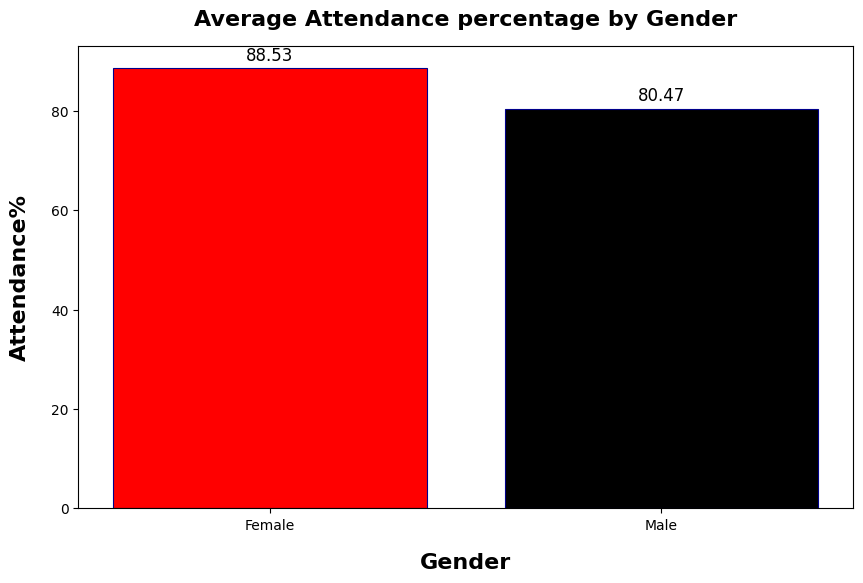

In [4]:
chart1_sql  = """
    SELECT gender,ROUND(AVG(attendance_percentage),2) AS avg_attendance
    FROM students
    GROUP BY gender
    ORDER BY avg_attendance DESC
    """
chart1_data = pd.read_sql_query(chart1_sql,conn)

#2: Create the bar chart
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=['red','black']
bars=ax.bar(
    chart1_data['gender'],
    chart1_data['avg_attendance'],
    color=bar_colors,
    edgecolor='darkblue',
    linewidth=0.8
)
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.2f}',
      ha='center',
      va='bottom',
      fontsize=12,
      color='black'
  )
ax.set_title("Average Attendance percentage by Gender",fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel("Gender",fontsize=16,fontweight='bold',labelpad=15)
ax.set_ylabel("Attendance%",fontsize=16,fontweight='bold',labelpad=15)

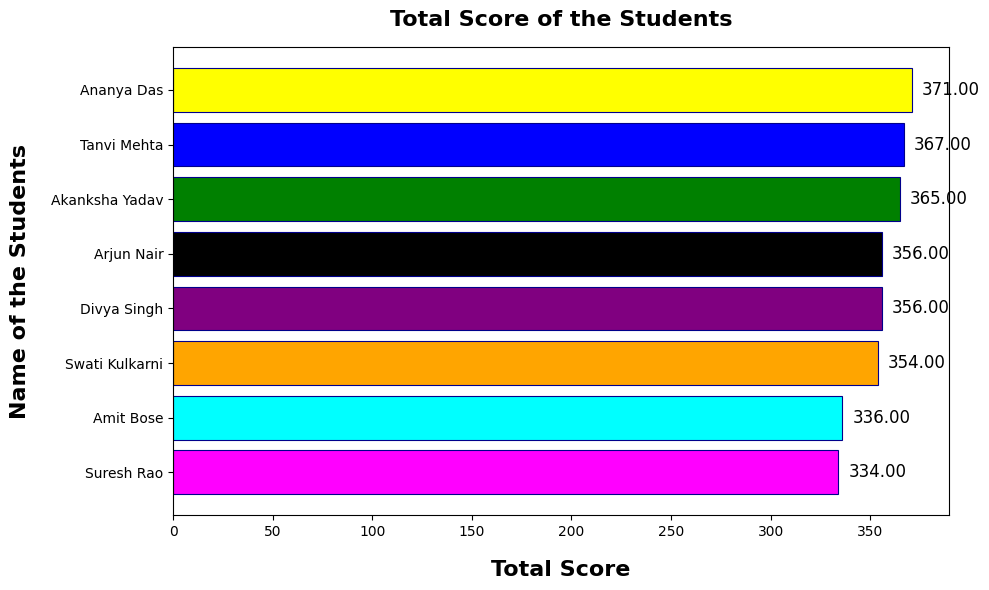

In [18]:
df['total_score']=df['math_score']+df['english_score']+df['science_score']+df['programming_score']
chart2_sql  = """
    SELECT name,
           math_score + english_score + science_score + programming_score AS total_score
    FROM students
    ORDER BY total_score DESC LIMIT 8
    """
chart2_data = pd.read_sql_query(chart2_sql,conn)

#2: Create the bar chart
fig,ax=plt.subplots(figsize=(10,6))
# Extend bar_colors to match the number of bars (8 in this case)
bar_colors=['yellow','blue','green','black','purple','orange','cyan','magenta']
bars=ax.barh(
    chart2_data['name'],
    chart2_data['total_score'],
    color=bar_colors,
    edgecolor='darkblue',
    linewidth=0.8
)
for bar in bars:
  width=bar.get_width()
  ax.text(
      width + 5, # X-position: end of bar + offset
      bar.get_y() + bar.get_height() / 2, # Y-position: center of bar
      f'{width:.2f}',
      ha='left', # Horizontal alignment to the left of the text
      va='center', # Vertical alignment to the center of the bar
      fontsize=12,
      color='black'
  )
ax.set_title("Total Score of the Students",fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel("Total Score",fontsize=16,fontweight='bold',labelpad=15) # Swapped xlabel and ylabel for barh
ax.set_ylabel("Name of the Students",fontsize=16,fontweight='bold',labelpad=15) # Swapped xlabel and ylabel for barh
ax.invert_yaxis() # To display the highest score at the top
plt.tight_layout() # Adjust layout to prevent labels from being cut off